In [1]:
from PIL import Image
from pdf2image import convert_from_path
from surya.ocr import run_ocr
from surya.model.detection.model import load_model as load_det_model, load_processor as load_det_processor
from surya.model.recognition.model import load_model as load_rec_model
from surya.model.recognition.processor import load_processor as load_rec_processor
from tqdm import tqdm

from huggingface_hub import hf_hub_download, list_repo_files
from datasets import load_dataset
import re
import os

/Applications/anaconda3/envs/ocr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rgs_dataset = load_dataset("placingholocaust/testimony-metadata")["train"]["RG Number"]

In [3]:
rgs = [re.sub(r'[^\w.-]', '', rg) for rg in rgs_dataset]
rgs[:5]

['RG-50.549.02.0033',
 'RG-50.549.02.0072',
 'RG-50.549.02.0035',
 'RG-50.471.0015',
 'RG-50.030.0585']

In [4]:
repo_id = "placingholocaust/ushmm-pdfs"

In [5]:
pdfs = list_repo_files(repo_id, repo_type="dataset")

In [6]:
filtered_pdfs = [pdf for pdf in pdfs if any(rg in pdf for rg in rgs) and "trs" in pdf]
filtered_pdfs[:5]

['pdfs/RG-50.030.0001_trs_en.pdf',
 'pdfs/RG-50.030.0002_trs_en.pdf',
 'pdfs/RG-50.030.0003_trs_en.pdf',
 'pdfs/RG-50.030.0004_trs_en.pdf',
 'pdfs/RG-50.030.0006_trs_en.pdf']

In [7]:
det_processor, det_model = load_det_processor(), load_det_model()
rec_model, rec_processor = load_rec_model(), load_rec_processor()

langs = ["en"]

Loaded detection model vikp/surya_det3 on device mps with dtype torch.float16
Loaded recognition model vikp/surya_rec2 on device mps with dtype torch.float16


In [8]:
import json

def save_predictions_to_json(all_predictions, filename):
    # Convert predictions to serializable format
    serializable_predictions = []
    for i, page_pred in enumerate(all_predictions):
        page_data = []
        for text_line in page_pred[0].text_lines:
            line_data = {
                'text': text_line.text.strip(),
                'confidence': float(text_line.confidence),
                'bbox': text_line.bbox.tolist() if hasattr(text_line.bbox, 'tolist') else text_line.bbox,
                'page': i + 1  # Add page number (1-based indexing)
            }
            page_data.append(line_data)
        serializable_predictions.append(page_data)

    # Save to JSON file
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(serializable_predictions, f, ensure_ascii=False, indent=2)


In [26]:
from copy import deepcopy
from typing import List
from PIL import Image

from surya.detection import batch_text_detection
from surya.input.processing import slice_polys_from_image, slice_bboxes_from_image, convert_if_not_rgb
from surya.postprocessing.text import sort_text_lines
from surya.recognition import batch_recognition
from surya.schema import TextLine, OCRResult

def sort_text_lines(lines, tolerance=None):
    # First sort by y-coordinate
    sorted_lines = sorted(lines, key=lambda x: x.bbox[1])
    
    # Initialize merged lines list
    merged_lines = []
    i = 0
    
    while i < len(sorted_lines):
        current_line = sorted_lines[i]
        current_text = current_line.text.strip()
        
        # Check if this is a Q: or A: line
        if current_text in ['Q:', 'A:'] and i + 1 < len(sorted_lines):
            next_line = sorted_lines[i + 1]
            y_diff = abs(next_line.bbox[1] - current_line.bbox[1])
            
            # If the next line is close enough vertically, merge them
            if y_diff < (tolerance or 20):  # Default tolerance of 20 pixels
                # Create new merged TextLine
                merged_text = f"{current_text} {next_line.text.strip()}"
                merged_confidence = (current_line.confidence + next_line.confidence) / 2
                
                # Use the bounding box that encompasses both lines
                merged_bbox = [
                    min(current_line.bbox[0], next_line.bbox[0]),  # x1
                    min(current_line.bbox[1], next_line.bbox[1]),  # y1
                    max(current_line.bbox[2], next_line.bbox[2]),  # x2
                    max(current_line.bbox[3], next_line.bbox[3])   # y2
                ]
                
                # Create merged polygon (use original polygon if needed)
                merged_polygon = current_line.polygon
                
                merged_line = TextLine(
                    text=merged_text,
                    polygon=merged_polygon,
                    bbox=merged_bbox,
                    confidence=merged_confidence
                )
                merged_lines.append(merged_line)
                i += 2  # Skip the next line since we merged it
                continue
                
        merged_lines.append(current_line)
        i += 1
    
    return merged_lines

def run_ocr2(images: List[Image.Image], langs: List[List[str] | None], det_model, det_processor, rec_model, rec_processor, batch_size=None, highres_images: List[Image.Image] | None = None, tolerance: int = None) -> List[OCRResult]:
    images = convert_if_not_rgb(images)
    highres_images = convert_if_not_rgb(highres_images) if highres_images is not None else [None] * len(images)
    det_predictions = batch_text_detection(images, det_model, det_processor)

    all_slices = []
    slice_map = []
    all_langs = []

    for idx, (det_pred, image, highres_image, lang) in enumerate(zip(det_predictions, images, highres_images, langs)):
        polygons = [p.polygon for p in det_pred.bboxes]
        if highres_image:
            width_scaler = highres_image.size[0] / image.size[0]
            height_scaler = highres_image.size[1] / image.size[1]
            scaled_polygons = [[[int(p[0] * width_scaler), int(p[1] * height_scaler)] for p in polygon] for polygon in polygons]
            slices = slice_polys_from_image(highres_image, scaled_polygons)
        else:
            slices = slice_polys_from_image(image, polygons)
        slice_map.append(len(slices))
        all_langs.extend([lang] * len(slices))
        all_slices.extend(slices)

    rec_predictions, confidence_scores = batch_recognition(all_slices, all_langs, rec_model, rec_processor, batch_size=batch_size)

    predictions_by_image = []
    slice_start = 0
    for idx, (image, det_pred, lang) in enumerate(zip(images, det_predictions, langs)):
        slice_end = slice_start + slice_map[idx]
        image_lines = rec_predictions[slice_start:slice_end]
        line_confidences = confidence_scores[slice_start:slice_end]
        slice_start = slice_end

        assert len(image_lines) == len(det_pred.bboxes)

        lines = []
        for text_line, confidence, bbox in zip(image_lines, line_confidences, det_pred.bboxes):
            lines.append(TextLine(
                text=text_line,
                polygon=bbox.polygon,
                bbox=bbox.bbox,
                confidence=confidence
            ))

        # Pass tolerance to sort_text_lines if provided
        lines = sort_text_lines(lines, tolerance=tolerance) if tolerance is not None else sort_text_lines(lines)

        predictions_by_image.append(OCRResult(
            text_lines=lines,
            languages=lang,
            image_bbox=det_pred.image_bbox
        ))

    return predictions_by_image

In [27]:
for filtered_pdf in tqdm(filtered_pdfs[:1]):
    hf_hub_download(repo_id="placingholocaust/ushmm-pdfs",
                    filename=filtered_pdf,
                    local_dir="../demo_output",
                    repo_type="dataset")
    images = convert_from_path(os.path.join("../demo_output", filtered_pdf))
    all_predictions = []
    for image in images[2:3]:
        predictions = run_ocr2([image], [langs], det_model, det_processor, rec_model, rec_processor, tolerance=.05)
        all_predictions.append(predictions)
    save_predictions_to_json(all_predictions, f"../demo_output/{filtered_pdf.replace('.pdf', '.json')}")

100%|██████████| 1/1 [00:09<00:00,  9.66s/it]


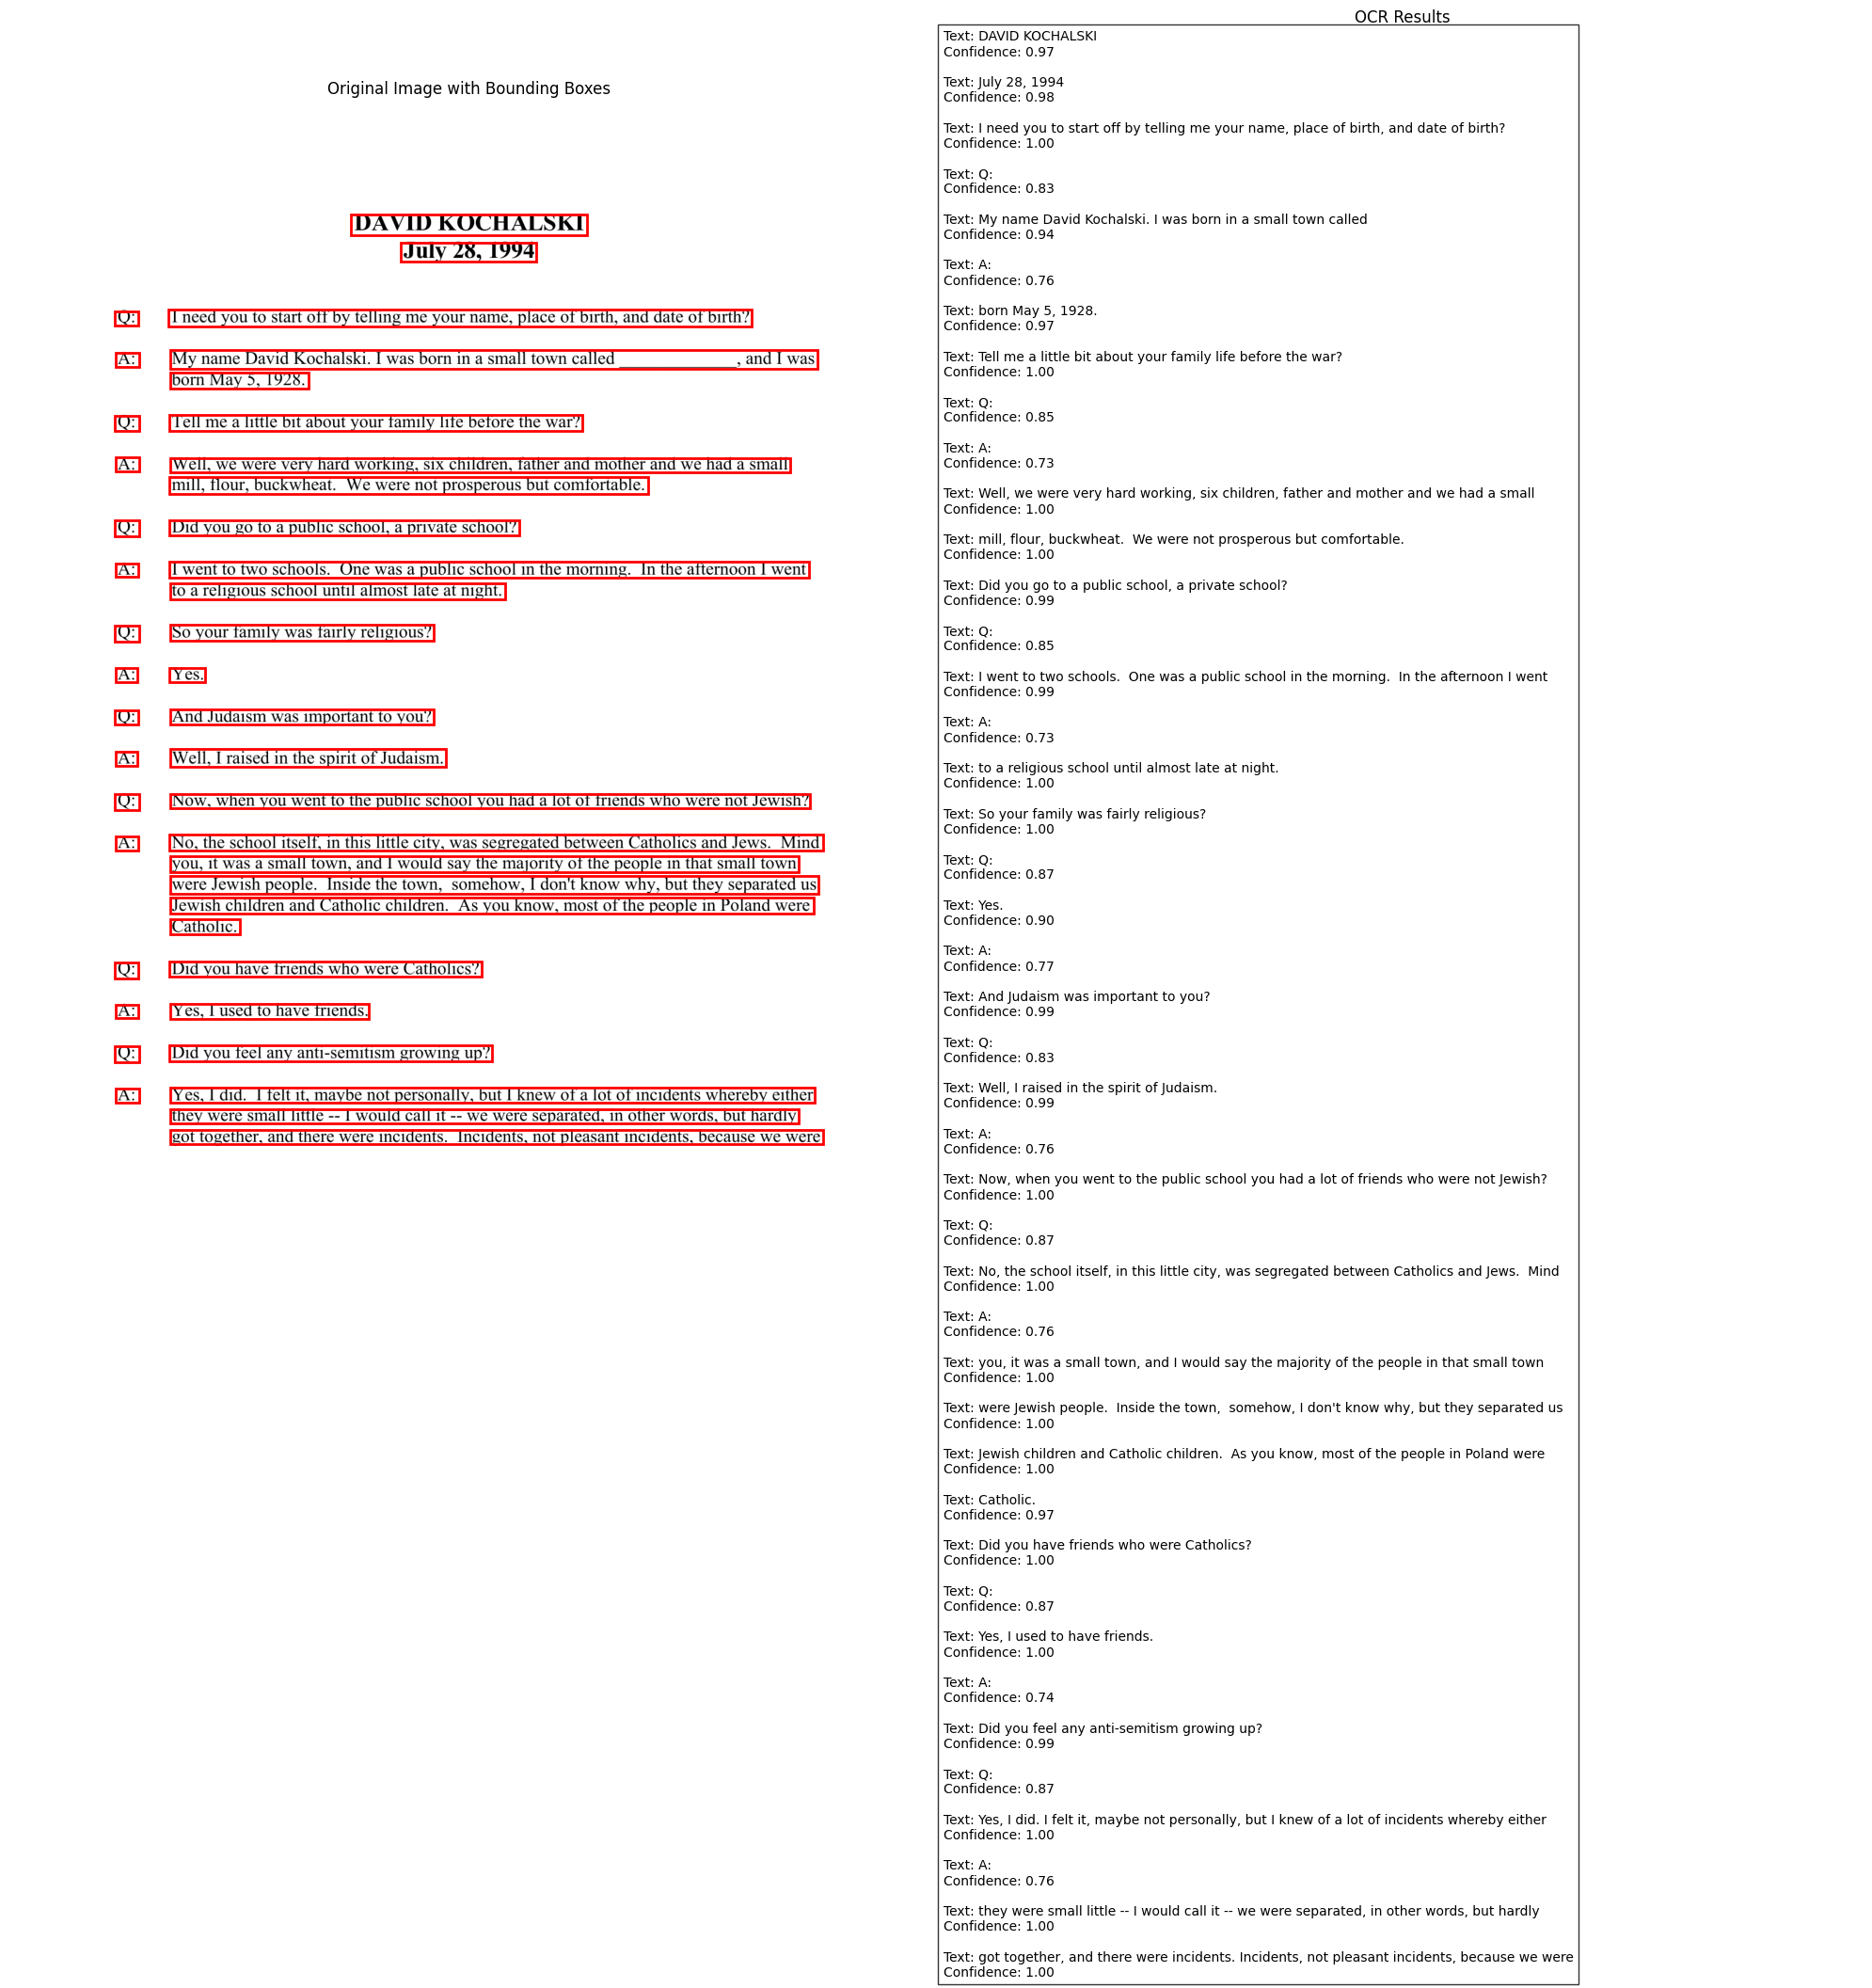

In [28]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from matplotlib.patches import Rectangle

def visualize_ocr_results_with_text_column(image, ocr_result):
    # Open and process the image
    # image = Image.open(image_path)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))
    
    # Display image with bounding boxes
    ax1.imshow(image)
    ax1.set_title("Original Image with Bounding Boxes")
    ax1.axis('off')
    
    # Draw bounding boxes
    for text_line in ocr_result.text_lines:
        bbox = text_line.bbox
        rect = Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                         fill=False, edgecolor='red', linewidth=2)
        ax1.add_patch(rect)
    
    # Display OCR results as text
    ax2.axis('off')
    ax2.set_title("OCR Results")
    
    # Check if the language is Hebrew
    is_hebrew = 'he' in ocr_result.languages
    
    text_content = "\n\n".join([
        f"Text: {line.text[::-1] if is_hebrew else line.text}\nConfidence: {line.confidence:.2f}" 
        for line in ocr_result.text_lines
    ])
    ax2.text(0, 1, text_content, fontsize=10, verticalalignment='top', 
             wrap=True, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Assuming 'predictions[0]' contains your OCR result
visualize_ocr_results_with_text_column(image, predictions[0])

In [12]:
import json

# Convert predictions to serializable format
serializable_predictions = []
for i, page_pred in enumerate(all_predictions):
    page_data = []
    for text_line in page_pred[0].text_lines:
        line_data = {
            'text': text_line.text.strip(),
            'confidence': float(text_line.confidence),
            'bbox': text_line.bbox.tolist() if hasattr(text_line.bbox, 'tolist') else text_line.bbox,
            'page': i + 1  # Add page number (1-based indexing)
        }
        page_data.append(line_data)
    serializable_predictions.append(page_data)

# Save to JSON file
with open('../demo_output/ocr_predictions.json', 'w', encoding='utf-8') as f:
    json.dump(serializable_predictions, f, ensure_ascii=False, indent=2)


In [8]:
page_predictions = []
for predictions in all_predictions:
    page_lines = []
    # Print all text lines from the OCR results
    for text_line in predictions[0].text_lines:
        page_lines.append(text_line.text.strip())
    page_predictions.append(page_lines)



In [9]:
from collections import Counter

# Flatten all page predictions into a single list of lines
all_lines = [line for page in page_predictions for line in page]

# Count occurrences of each line
line_counts = Counter(all_lines)

# Get the 10 most common lines and their counts
most_common_lines = line_counts.most_common(10)

print("Most common lines in the document:")
print("-" * 50)
for line, count in most_common_lines:
    print(f"Count: {count:3d} | {line}")


Most common lines in the document:
--------------------------------------------------
Count: 185 | http://collections.ushmm.org
Count: 185 | Contact reference@ushmm.org for further information about this collection
Count: 185 | This is a verbatim transcript of spoken word. It is not the primary source, and it has not been checked for spelling or accuracy.
Count: 182 | USHMM Archives RG-50.030*0469
Count:  91 | Q: Right.
Count:  51 | A: Yes.
Count:  41 | A: Yeah.
Count:  39 | Q: Yes.
Count:  34 | Q: Uh-huh.
Count:  34 | Q: Yeah.


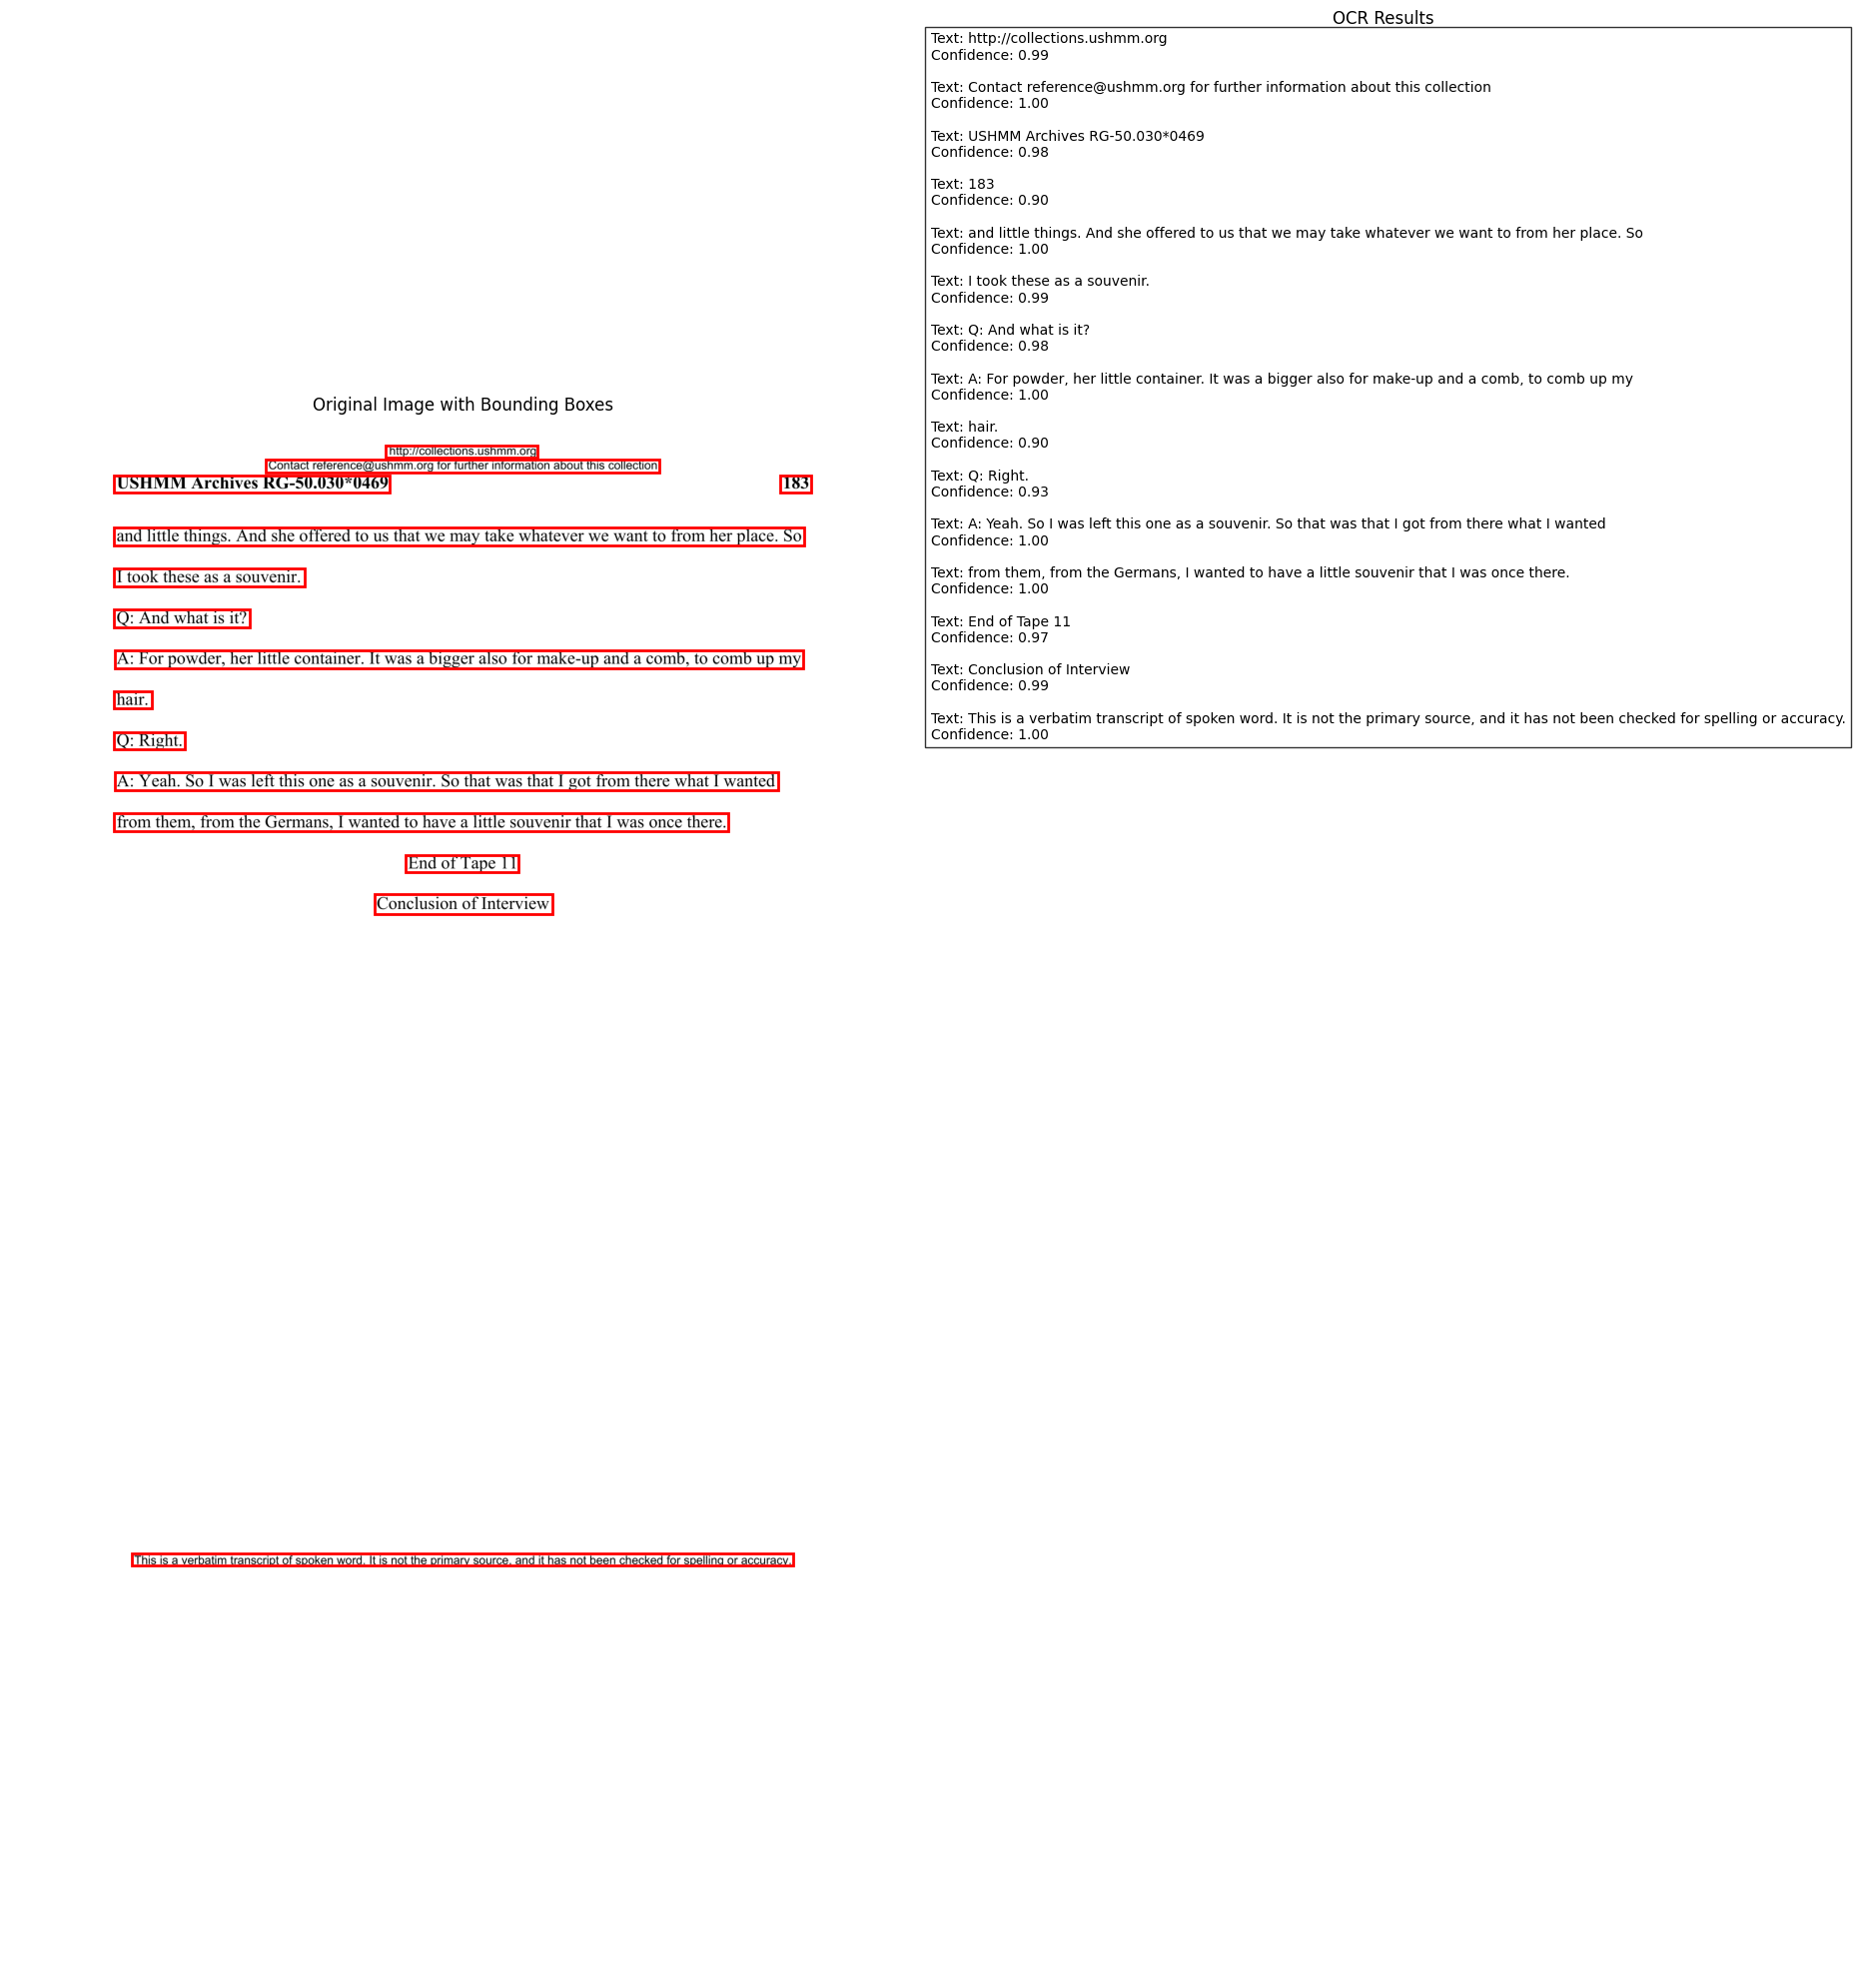

In [10]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from matplotlib.patches import Rectangle

def visualize_ocr_results_with_text_column(image, ocr_result):
    # Open and process the image
    # image = Image.open(image_path)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))
    
    # Display image with bounding boxes
    ax1.imshow(image)
    ax1.set_title("Original Image with Bounding Boxes")
    ax1.axis('off')
    
    # Draw bounding boxes
    for text_line in ocr_result.text_lines:
        bbox = text_line.bbox
        rect = Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                         fill=False, edgecolor='red', linewidth=2)
        ax1.add_patch(rect)
    
    # Display OCR results as text
    ax2.axis('off')
    ax2.set_title("OCR Results")
    
    # Check if the language is Hebrew
    is_hebrew = 'he' in ocr_result.languages
    
    text_content = "\n\n".join([
        f"Text: {line.text[::-1] if is_hebrew else line.text}\nConfidence: {line.confidence:.2f}" 
        for line in ocr_result.text_lines
    ])
    ax2.text(0, 1, text_content, fontsize=10, verticalalignment='top', 
             wrap=True, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Assuming 'predictions[0]' contains your OCR result
visualize_ocr_results_with_text_column(image, predictions[0])